# Import de libs

In [57]:
# importing necessary modules
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import beta as beta_dist
from scipy.stats import norm as norm_dist
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from tqdm import tqdm
from sklearn.linear_model import SGDClassifier, LogisticRegression
from scipy.optimize import minimize
from statsmodels.tools.tools import add_constant
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

# OnlineLogisticRegression

In [24]:
class OnlineLogisticRegression:
    def __init__(self, lambda_, alpha, n_dim):
        self.lambda_ = lambda_
        self.alpha = alpha
        self.n_dim = n_dim 
        
        # Inicializa parâmetros com a dimensão correta das features
        self.m = np.zeros(self.n_dim)
        self.q = np.ones(self.n_dim) * self.lambda_
        self.w = np.random.normal(self.m, self.alpha * (self.q)**(-1.0), size=self.n_dim)

        # Novo: Histórico para visualização
        self.history = []
        
    def loss(self, w, *args):
        X, y = args
        # Convertemos para numpy para evitar o KeyError do Pandas
        X_np = X.values if hasattr(X, 'values') else X
        y_np = y.values if hasattr(y, 'values') else y
        
        # Termo de regularização + Log-Likelihood
        return 0.5 * (self.q * (w - self.m)).dot(w - self.m) + \
               np.sum([np.log(1 + np.exp(-y_np[j] * w.dot(X_np[j]))) for j in range(len(y_np))])
        
    def grad(self, w, *args):
        X, y = args
        X_np = X.values if hasattr(X, 'values') else X
        y_np = y.values if hasattr(y, 'values') else y
        
        return self.q * (w - self.m) + \
               (-1) * np.array([y_np[j] * X_np[j] / (1. + np.exp(y_np[j] * w.dot(X_np[j]))) 
                               for j in range(len(y_np))]).sum(axis=0)
    
    def get_weights(self):
        return np.random.normal(self.m, self.alpha * (self.q)**(-1.0), size=self.n_dim)
    
    def fit(self, X, y):
        X_np = np.array(X.values if hasattr(X, 'values') else X, dtype=np.float64)
        y_np = np.array(y.values if hasattr(y, 'values') else y, dtype=np.float64)
        
        self.w = minimize(self.loss, self.w, args=(X_np, y_np), jac=self.grad, method="L-BFGS-B", options={'maxiter': 20}).x
        self.m = self.w
        
        dot_product = np.dot(X_np, self.m).astype(np.float64)
        P = 1.0 / (1.0 + np.exp(-1.0 * dot_product))
        self.q = self.q + (P * (1.0 - P)).dot(X_np ** 2)
        
        # Salva o estado atual dos parâmetros
        self.history.append({'m': self.m.copy(), 'q': self.q.copy()})
                
    def predict_proba(self, X, mode='sample'):
        w = self.get_weights() if mode == 'sample' else self.m
        
        # Força X e w a serem float64 para evitar o erro de ufunc
        X_input = np.array(X, dtype=np.float64)
        dot_product = np.dot(X_input, w).astype(np.float64)
        
        proba = 1.0 / (1.0 + np.exp(-1.0 * dot_product))
        return np.array([1.0 - proba, proba]).T

# ThompsonSamplingLR

In [25]:
class ThompsonSamplingLR:
    def __init__(self, lambda_, alpha, n_bandits, n_dim, buffer_size=200):
        self.lambda_ = lambda_
        self.alpha = alpha
        self.n_bandits = n_bandits
        self.n_dim = n_dim # Agora dinâmico
        self.buffer_size = buffer_size
    
    def fit_predict(self, df_bandit, actual_x):
        X_train = df_bandit[feature_cols]
        y_train = df_bandit['reward']
        
        olr = OnlineLogisticRegression(self.lambda_, self.alpha, self.n_dim)
        olr.fit(X_train, y_train)
        
        # Garante que actual_x seja um array numérico
        context = np.array(actual_x, dtype=np.float64)
        prediction = olr.predict_proba(context)
            
        return pd.Series({'prob': prediction[1]})
    
    def choose_bandit(self, round_df, actual_x):
        round_df = round_df.tail(self.buffer_size)
        
        # Verifica se há dados de sucesso e falha para o braço ter variabilidade
        counts = round_df.groupby(['k', 'reward']).size().unstack(fill_value=0)
        
        if len(counts) >= 1: # Se temos dados históricos
            # Aplica o fit_predict para cada produto (k) de forma independente
            probs = round_df.groupby('k').apply(lambda x: self.fit_predict(x, actual_x))
            best_bandit = int(probs['prob'].idxmax())
        else:
            best_bandit = np.random.randint(0, self.n_bandits)
            
        return best_bandit

# Application

## Data

In [4]:
def engineer_features(df, product_meta):
    # Merge product metadata (margin, category, etc.)
    df = df.merge(product_meta, on='produto', how='left')
    
    # 1. Target Variable: Conversion (Click + Purchase)
    # You can also train two separate models, but for a carousel, 
    # we usually optimize for the final 'Purchase'.
    df['target'] = df['contratou']
    
    # 2. De-biasing Rank:
    # Since Rank 1 gets more clicks naturally, we treat 'rank' as a feature 
    # during training to capture that bias.
    
    # 3. Categorical Encoding
    df = pd.get_dummies(df, columns=['segmento', 'canal', 'categoria'])
    
    # 4. Filter only active products for the current recommendation
    # df = df[df['is_active'] == 1]
    
    return df

In [5]:
clientes = pd.read_csv('data/clientes.csv')
contratos_ativos = pd.read_csv('data/contratos_ativos.csv')
interacoes = pd.read_csv('data/interacoes.csv')
produtos = pd.read_csv('data/produtos.csv')

In [6]:
raw_data = interacoes[[
    'id_cliente', 
    'produto', 
    'posicao_exibicao', 
    'canal', 
    'clicou', 
    'contratou', 
    'receita_gerada',
    'safra'
    ]]

In [7]:
raw_data = raw_data.merge(
    clientes[[
        'id_cliente', 
        'idade', 
        'segmento'
        ]],
    on='id_cliente', 
    how='left')

In [8]:
raw_data = raw_data[[
    'id_cliente', 
    'produto', 
    'posicao_exibicao', 
    'canal', 
    'idade', 
    'segmento',
    'clicou', 
    'contratou', 
    'receita_gerada', 
    'safra' 
    ]]

In [9]:
meta = produtos[['produto', 'categoria', 'margem', 'receita_media', 'custo_aquisicao']]

In [10]:
processed_data = engineer_features(raw_data, meta)

In [11]:
# map each product to an arm index and define contextual features
processed_data['product_code'] = processed_data['produto'].astype('category').cat.codes
processed_data['k'] = processed_data['product_code']
processed_data['reward'] = processed_data['contratou']
product_code_to_name = dict(enumerate(processed_data['produto'].astype('category').cat.categories))

feature_cols = [
    'posicao_exibicao', 'idade'
]
feature_cols += [c for c in processed_data.columns if c.startswith('categoria_') or c.startswith('segmento_')]

In [12]:
feature_cols

['posicao_exibicao',
 'idade',
 'segmento_basico',
 'segmento_intermediario',
 'segmento_premium',
 'categoria_capitalizacao',
 'categoria_cartao',
 'categoria_consorcio',
 'categoria_conta',
 'categoria_credito',
 'categoria_investimento',
 'categoria_seguro']

In [13]:
df_train = (
    processed_data[processed_data.safra < 202511]
    [feature_cols + ['k', 'reward']]
)

df_test = (
    processed_data[processed_data.safra >= 202511]
    [feature_cols + ['k', 'reward']]
)

## Training and predicting

In [50]:
# 1. Treinar um modelo por produto (k) usando dados de treino
modelos_por_produto = {}
for k in df_train['k'].unique():
    dados_k = df_train[df_train['k'] == k]
    olr = OnlineLogisticRegression(lambda_=1.0, alpha=2.0, n_dim=len(feature_cols))
    olr.fit(dados_k[feature_cols], dados_k['reward'])
    modelos_por_produto[k] = olr

# 2. Avaliação no Teste (Amostra de clientes para performance)
resultados_ranking = []
df_test['posicao_exibicao'] = 1
clientes_teste = df_test.index.unique()[:] # Limite para exemplo

for idx in tqdm(clientes_teste):
    row = df_test.loc[idx]
    # Se houver múltiplas interações para o mesmo cliente, pegamos a primeira
    # if isinstance(row, pd.DataFrame): row = row.iloc[0]
    
    contexto = row[feature_cols].values
    target_real = row['reward']
    produto_real = row['k']
    
    probs_produtos = {}
    for k, model in modelos_por_produto.items():
        # Amostragem de Thompson
        p = model.predict_proba(contexto.reshape(1, -1), mode='sample')[0, 1]
        probs_produtos[k] = p
        
    # Ordena produtos por probabilidade amostrada
    ranking = sorted(probs_produtos, key=probs_produtos.get, reverse=True)
    top_5 = ranking[:5]
    
    # Verifica se o produto contratado (se houver) está no Top 5
    acertou_top5 = (target_real == 1) and (produto_real in top_5)
    
    resultados_ranking.append({
        'produto_real': produto_real,
        'contratou': target_real,
        'top_5': top_5,
        'no_top_5': produto_real in top_5
    })

df_resun = pd.DataFrame(resultados_ranking)
print(f"Conversões no Top 5: {df_resun[df_resun['contratou']==1]['no_top_5'].mean():.2%}")

100%|██████████| 39907/39907 [00:23<00:00, 1695.64it/s]

Conversões no Top 5: 69.47%


In [62]:
# Baseline 1: Ranking por Popularidade (Geral nos dados de treino)
popularidade = df_train.groupby('k')['reward'].sum().sort_values(ascending=False)
ranking_popular = popularidade.index.tolist()

# Baseline 2: Ranking Aleatório
todos_produtos = df_train['k'].unique().tolist()

def get_random_ranking(produtos):
    ranking = produtos.copy()
    np.random.shuffle(ranking)
    return ranking

In [64]:
resultados_comparativos = []
clientes_teste = df_test.index.unique()[:] 

for idx in tqdm(clientes_teste):
    row = df_test.loc[idx]
    if isinstance(row, pd.DataFrame): row = row.iloc[0]
    
    contexto = row[feature_cols].values
    produto_real = int(row['k'])
    contratou = int(row['reward'])
    
    # --- Modelo Thompson Sampling ---
    probs_ts = {}
    for k, model in modelos_por_produto.items():
        p = model.predict_proba(contexto.reshape(1, -1), mode='sample')[0, 1]
        probs_ts[k] = p
    ranking_ts = sorted(probs_ts, key=probs_ts.get, reverse=True)
    
    # --- Baseline Aleatório ---
    ranking_rand = get_random_ranking(todos_produtos)
    
    # --- Avaliação ---
    resultados_comparativos.append({
        'contratou': contratou,
        'ts_hit': produto_real in ranking_ts[:5],
        'pop_hit': produto_real in ranking_popular[:5],
        'rand_hit': produto_real in ranking_rand[:5]
    })

df_comp = pd.DataFrame(resultados_comparativos)

100%|██████████| 39907/39907 [00:24<00:00, 1635.80it/s]


In [67]:
resultados_comparativos = []
clientes_teste = df_test.index.unique()[:] 

for idx in tqdm(clientes_teste):
    row = df_test.loc[idx]
    if isinstance(row, pd.DataFrame): row = row.iloc[0]
    
    contexto = row[feature_cols].values
    produto_real = int(row['k'])
    contratou = int(row['reward'])
    
    # --- Modelo Thompson Sampling ---
    probs_ts = {}
    for k, model in modelos_por_produto.items():
        p = model.predict_proba(contexto.reshape(1, -1), mode='sample')[0, 1]
        probs_ts[k] = p
    ranking_ts = sorted(probs_ts, key=probs_ts.get, reverse=True)
    
    # --- Baseline Aleatório ---
    ranking_rand = get_random_ranking(todos_produtos)
    
    # --- Avaliação ---
    resultados_comparativos.append({
        'contratou': contratou,
        'ts_hit': produto_real in ranking_ts[:5],
        'pop_hit': produto_real in ranking_popular[:5],
        'rand_hit': produto_real in ranking_rand[:5]
    })

df_comp = pd.DataFrame(resultados_comparativos)

100%|██████████| 39907/39907 [00:23<00:00, 1668.00it/s]


In [69]:
df_comp[df_comp.contratou == 1].mean()

contratou    1.000000
ts_hit       0.691877
pop_hit      0.669468
rand_hit     0.243697
dtype: float64

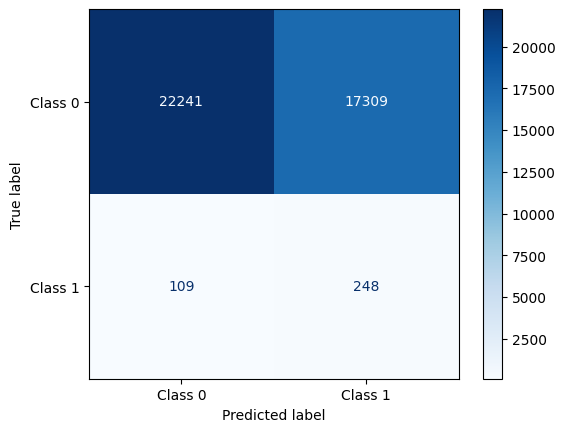

In [ ]:
cm = confusion_matrix(df_resun.contratou, df_resun.no_top_5)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'],
                               )

# Plot it
disp.plot(cmap=plt.cm.Blues)
plt.show()